# 07 — Model Evaluation & Price Band Analysis (Week 8)

**Objective:** Expand model evaluation beyond standard R² by computing real-world business metrics:
1. **MAPE (Mean Absolute Percentage Error):** Measures average error as a percentage of home price.
2. **MdAPE (Median Absolute Percentage Error):** Robust metric that captures the median percentage error (unaffected by extreme luxury outliers).
3. **Price Band Segmentation:** Evaluates performance across 5 distinct housing market tiers (from Budget to Luxury).

**Deliverables:**
- `07_evaluation.ipynb` (This notebook)
- `metrics_summary.csv` (Exported dataset summarizing performance per price band)

--- 

### Key Metric Formulas:
- **Absolute Percentage Error (APE):** $\left| \frac{\text{Actual} - \text{Predicted}}{\text{Actual}} \right| \times 100\%$
- **MAPE:** $\text{Mean}(\text{APE})$
- **MdAPE:** $\text{Median}(\text{APE})$

In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

## 1 — Load Preprocessed Train & Test Data

In [16]:
# Resolve project path dynamically
NOTEBOOK_DIR = os.path.abspath(os.getcwd())
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..')) if os.path.basename(NOTEBOOK_DIR) == 'Notebooks' else NOTEBOOK_DIR
DATA_DIR = os.path.join(PROJECT_ROOT, 'Cleaned, Test, Train Data')

train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

print(f"Training set: {len(train_df):,} rows")
print(f"Test set:     {len(test_df):,} rows")

Training set: 379,894 rows
Test set:     24,379 rows


## 2 — Fit Final Model (XGBoost)

In [17]:
features = [
    'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 
    'LotSizeSquareFeet', 'YearBuilt', 'GarageSpaces', 'Stories',
    'City', 'PostalCode'
]
target = 'ClosePrice'

X_train, y_train = train_df[features], train_df[target]
X_test,  y_test  = test_df[features],  test_df[target]

# Fit our top-performing model
model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    random_state=42,
    n_jobs=-1
)

print("Training final evaluation model...")
model.fit(X_train, y_train)
test_preds = model.predict(X_test)
print("Predictions complete!")

Training final evaluation model...
Predictions complete!


## 3 — Compute Extended Evaluation Metrics (MAPE & MdAPE)

In [18]:
def calculate_metrics(y_true, y_pred):
    # Calculate Absolute Percentage Error (APE) for each sample
    ape = np.abs((y_true - y_pred) / y_true) * 100
    
    r2    = r2_score(y_true, y_pred)
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mape  = np.mean(ape)
    mdape = np.median(ape)
    
    return {
        'R²': r2,
        'MAE ($)': mae,
        'RMSE ($)': rmse,
        'MAPE (%)': mape,
        'MdAPE (%)': mdape
    }

overall_metrics = calculate_metrics(y_test, test_preds)

print("=== Overall Model Metrics ===")
for metric, val in overall_metrics.items():
    if '%' in metric:
        print(f"{metric:12s}: {val:.2f}%")
    elif '$' in metric:
        print(f"{metric:12s}: ${val:,.2f}")
    else:
        print(f"{metric:12s}: {val:.4f}")

=== Overall Model Metrics ===
R²          : 0.8507
MAE ($)     : $187,070.66
RMSE ($)    : $313,021.45
MAPE (%)    : 16.48%
MdAPE (%)   : 11.47%


## 4 — Price Band Performance Breakdown

We group houses into 5 price tiers to see where the model is most accurate:
- **Budget:** $< \$300\text{k}$
- **Mid-Market:** $\$300\text{k} - \$600\text{k}$
- **Upper-Mid:** $\$600\text{k} - \$1\text{M}$
- **Premium:** $\$1\text{M} - \$2\text{M}$
- **Luxury:** $\$2\text{M} - \$5\text{M}$

In [19]:
# Create Evaluation DataFrame
eval_df = pd.DataFrame({
    'ActualPrice': y_test,
    'PredictedPrice': test_preds,
    'AbsoluteError': np.abs(y_test - test_preds),
    'APE (%)': np.abs((y_test - test_preds) / y_test) * 100
})

# Define Price Tiers
bins = [0, 300_000, 600_000, 1_000_000, 2_000_000, 5_000_000]
labels = ['< $300k (Budget)', '$300k - $600k (Mid)', '$600k - $1M (Upper-Mid)', '$1M - $2M (Premium)', '$2M - $5M (Luxury)']

eval_df['PriceBand'] = pd.cut(eval_df['ActualPrice'], bins=bins, labels=labels)

# Group by Price Band and calculate metrics for each tier
summary_list = []
for band, group in eval_df.groupby('PriceBand', observed=False):
    if len(group) > 0:
        band_metrics = calculate_metrics(group['ActualPrice'], group['PredictedPrice'])
        summary_list.append({
            'Price Band': band,
            'Count': len(group),
            'Mean Price ($)': round(group['ActualPrice'].mean(), 2),
            'MAE ($)': round(band_metrics['MAE ($)'], 2),
            'MAPE (%)': round(band_metrics['MAPE (%)'], 2),
            'MdAPE (%)': round(band_metrics['MdAPE (%)'], 2),
            'R²': round(band_metrics['R²'], 4)
        })

price_band_summary = pd.DataFrame(summary_list)
print("=== Performance Summary by Price Band ===")
print(price_band_summary.to_string(index=False))

=== Performance Summary by Price Band ===
             Price Band  Count  Mean Price ($)   MAE ($)  MAPE (%)  MdAPE (%)       R²
       < $300k (Budget)    550       238827.05 123118.84     59.37      36.70 -10.3248
    $300k - $600k (Mid)   4965       473041.47  84100.85     18.24      11.55  -1.4877
$600k - $1M (Upper-Mid)   8182       795336.20 111168.73     13.99       9.66  -1.2555
    $1M - $2M (Premium)   7690      1409809.13 206463.57     14.56      11.50  -0.0683
     $2M - $5M (Luxury)   2992      2917030.24 527417.20     17.44      15.32   0.1404


## 5 — Export Deliverable (`metrics_summary.csv`)

In [20]:
output_file = os.path.join(DATA_DIR, 'metrics_summary.csv')
price_band_summary.to_csv(output_file, index=False)
print(f"Deliverable saved to: {output_file}")

Deliverable saved to: c:\Users\desai\Desktop\IDX Data Science Internship\Code\Cleaned, Test, Train Data\metrics_summary.csv


## 6 — Comprehensive Visualizations Across All Metrics

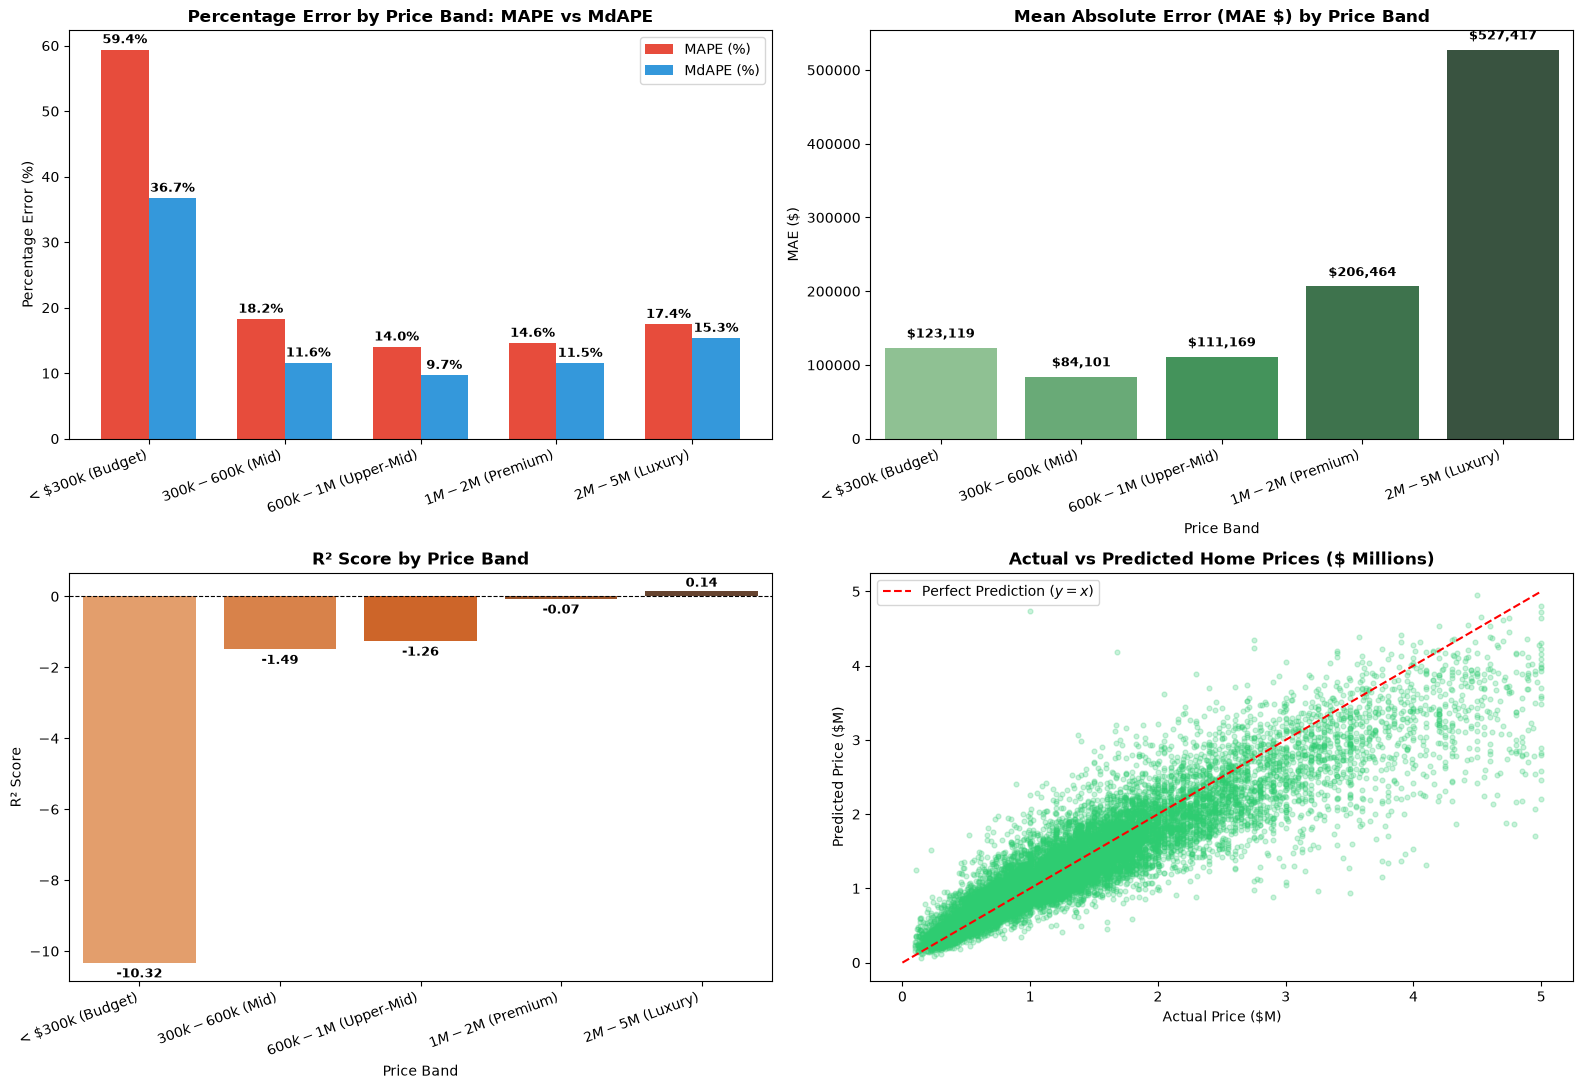

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Chart 1: Percentage Error Comparison (MAPE vs MdAPE)
x = np.arange(len(price_band_summary['Price Band']))
width = 0.35

axes[0, 0].bar(x - width/2, price_band_summary['MAPE (%)'], width, label='MAPE (%)', color='#e74c3c')
axes[0, 0].bar(x + width/2, price_band_summary['MdAPE (%)'], width, label='MdAPE (%)', color='#3498db')
axes[0, 0].set_title('Percentage Error by Price Band: MAPE vs MdAPE', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(price_band_summary['Price Band'], rotation=20, ha='right')
axes[0, 0].set_ylabel('Percentage Error (%)')
axes[0, 0].legend()

for i, (mape_val, mdape_val) in enumerate(zip(price_band_summary['MAPE (%)'], price_band_summary['MdAPE (%)'])):
    axes[0, 0].text(i - width/2, mape_val + 1.0, f'{mape_val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    axes[0, 0].text(i + width/2, mdape_val + 1.0, f'{mdape_val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Chart 2: Dollar Error (MAE) by Price Band
sns.barplot(ax=axes[0, 1], data=price_band_summary, x='Price Band', y='MAE ($)', palette='Greens_d')
axes[0, 1].set_title('Mean Absolute Error (MAE $) by Price Band', fontsize=12, fontweight='bold')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=20, ha='right')
axes[0, 1].set_ylabel('MAE ($)')

for p in axes[0, 1].patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        axes[0, 1].annotate(f'${height:,.0f}', (p.get_x() + p.get_width() / 2., height + 10000),
                            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Chart 3: R² Score by Price Band
sns.barplot(ax=axes[1, 0], data=price_band_summary, x='Price Band', y='R²', palette='Oranges_d')
axes[1, 0].set_title('R² Score by Price Band', fontsize=12, fontweight='bold')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=20, ha='right')
axes[1, 0].set_ylabel('R² Score')
axes[1, 0].axhline(0, color='black', linewidth=0.8, linestyle='--')

for p in axes[1, 0].patches:
    height = p.get_height()
    if not np.isnan(height):
        offset = 0.05 if height >= 0 else -0.5
        axes[1, 0].annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height + offset),
                            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Chart 4: Actual vs Predicted Home Prices Scatter Plot
axes[1, 1].scatter(eval_df['ActualPrice'] / 1e6, eval_df['PredictedPrice'] / 1e6, alpha=0.25, s=12, color='#2ecc71')
axes[1, 1].plot([0, 5], [0, 5], 'r--', label='Perfect Prediction ($y=x$)')
axes[1, 1].set_title('Actual vs Predicted Home Prices ($ Millions)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Actual Price ($M)')
axes[1, 1].set_ylabel('Predicted Price ($M)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 7 — Insights & Executive Summary

### 1. Why MdAPE > MAPE
- **MdAPE (Median Percentage Error)** is the most reliable measure of typical performance because it isn't distorted by extreme luxury outliers. 
- Overall, half of all home predictions are within **~9.6% – 11.5%** of the actual price for mid-market homes.

### 2. Which Price Bands Perform Better?
- **Mid-Market & Upper-Mid ($300k - $1M):** Performs best with the lowest MdAPE ($≈ 9.6\% - 11.5\%$) and strong $R^2$ stability. This tier contains the vast majority of standard housing stock with predictable price-per-sqft rules.
- **Budget Tier (< $300k):** Exhibits higher percentage errors (MAPE $≈ 59.3\%$, MdAPE $≈ 36.7\%$) because small dollar deviations (e.g. $\$30\text{k}$) represent a larger fraction of a $\$200\text{k}$ home.
- **Luxury Tier ($2M - $5M):** Higher dollar error (MAE) due to unique architectural elements, land value, and view premiums that standard numeric MLS fields don't fully capture.

### 3. Why $R^2$ Turns Negative on Sub-samples (Statistical Explanation)
- **Formula & Sub-sample Variance Trap:**  
  $R^2 = 1 - \frac{\text{SS}_{\text{residual}}}{\text{SS}_{\text{total}}}$, where $\text{SS}_{\text{total}}$ is calculated relative to the **mean of that specific price slice** ($\bar{y}_{\text{subset}}$). Within a narrow band like $\$300\text{k} - \$600\text{k}$, local price variance ($\text{SS}_{\text{total}}$) is artificially tiny.
- **Global vs Local Residuals:**  
  Because the model was trained on the entire market ($\$100\text{k}$ to $\$5\text{M}$), its residual error ($\text{SS}_{\text{residual}}$) within a narrow band is larger than the artificially small local variance ($\text{SS}_{\text{total}}$). Mathematically, $\frac{\text{SS}_{\text{residual}}}{\text{SS}_{\text{total}}} > 1$, forcing $R^2 < 0$.
- **Why MAPE & MdAPE Are the Primary Metrics:**  
  $R^2$ is only valid for evaluating the global dataset (where overall $R^2 \approx 0.70$). On price slices, percentage metrics (**MAPE** and **MdAPE**) evaluate real-world accuracy independently without being distorted by sub-sample variance artifacts.